In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,f1_score,precision_score

In [2]:
data=pd.read_csv(r'water_quality_potability.csv')
data.head(5)

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.160466,195.712338,22636.785632,7.235746,336.794067,424.396711,14.376178,68.105888,3.991681,1
1,7.187738,193.202237,21263.028076,7.117409,333.997161,430.163405,14.206928,64.807703,3.957064,0
2,5.400302,140.739062,17266.593422,10.056852,328.358241,472.874073,11.256381,56.931906,4.824786,0
3,7.078913,196.886558,21539.185679,7.104867,335.223406,429.400333,14.344261,65.289765,3.909317,0
4,7.052283,194.971523,21659.468727,7.101790,335.669903,425.620822,14.100794,66.178504,3.989340,0


In [3]:
corr_data=data.corr()

<Axes: >

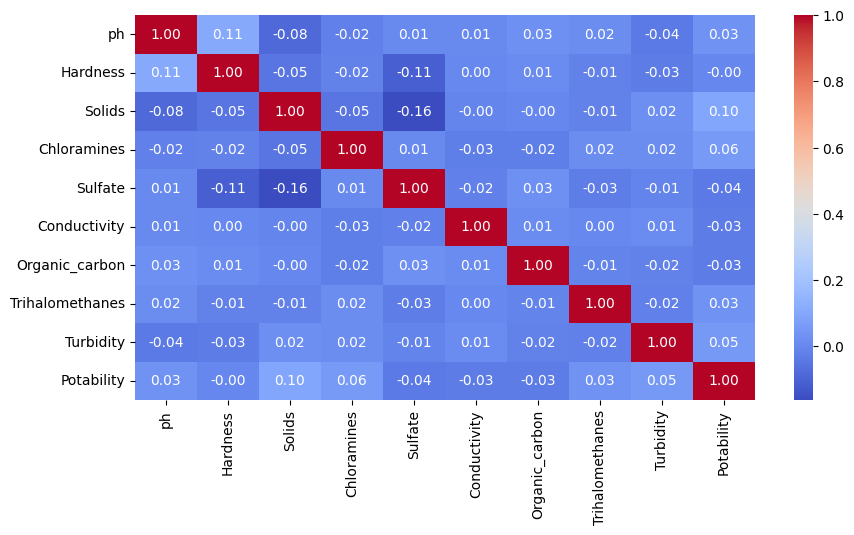

In [4]:
plt.figure(figsize=(10,5))
sns.heatmap(corr_data,fmt='.2f',annot=True,cmap='coolwarm')

C:\Users\Master\AppData\Local\Temp\ipykernel_12228\2290517714.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data['ph'],palette='catagorical',markers='--')


<Axes: ylabel='ph'>

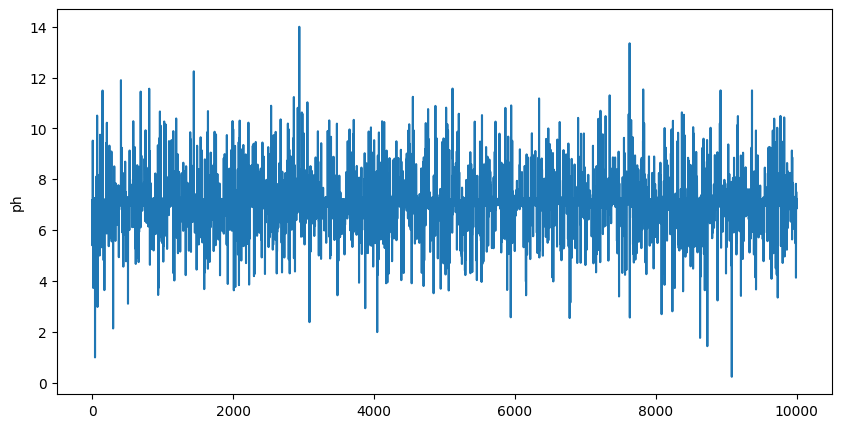

In [5]:
ph_data=data['Hardness'].value_counts()
plt.figure(figsize=(10,5))
sns.lineplot(data['ph'],palette='catagorical',markers='--')


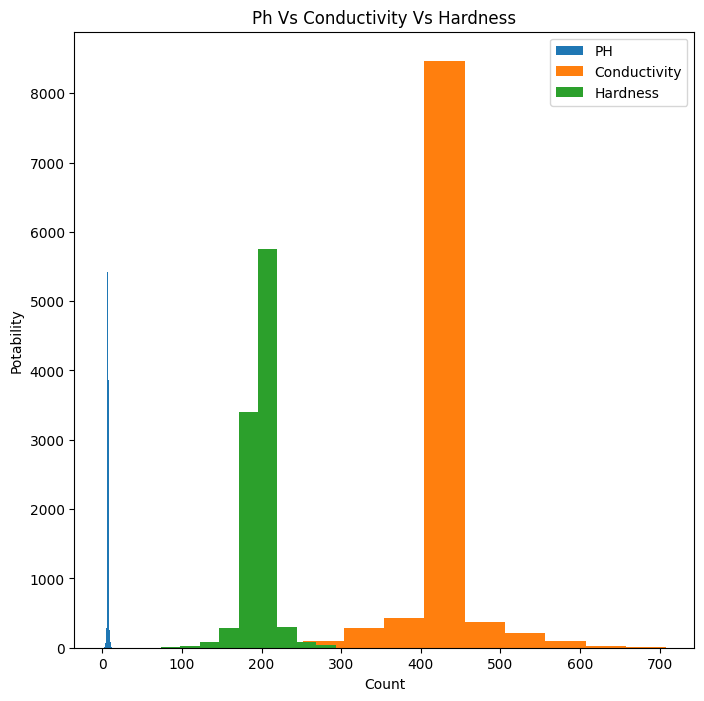

In [6]:
plt.figure(figsize=(8,8))
plt.hist(data['ph'],label='PH')
plt.hist(data['Conductivity'],label='Conductivity')
plt.hist(data['Hardness'],label='Hardness')
plt.title('Ph Vs Conductivity Vs Hardness')
plt.ylabel('Potability')
plt.xlabel('Count')
plt.legend()
plt.show()

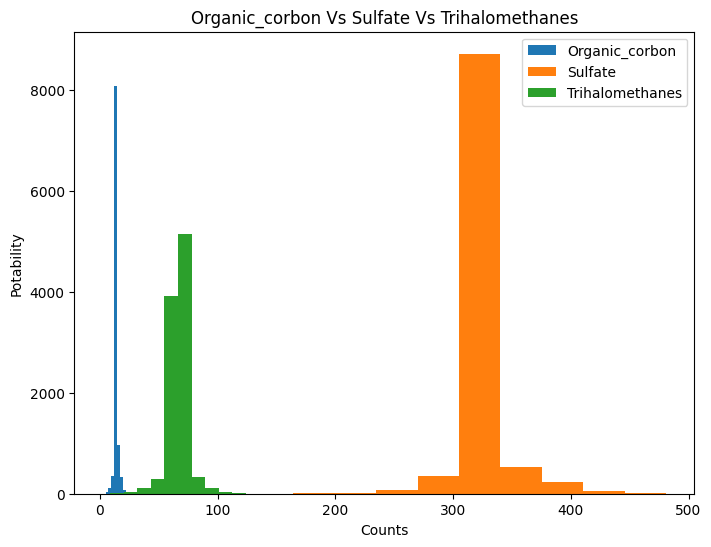

In [7]:
plt.figure(figsize=(8,6))
plt.hist(data['Organic_carbon'],label='Organic_corbon')
plt.hist(data['Sulfate'],label='Sulfate')
plt.hist(data['Trihalomethanes'],label='Trihalomethanes')
plt.ylabel('Potability')
plt.xlabel('Counts')
plt.title('Organic_corbon Vs Sulfate Vs Trihalomethanes')
plt.legend()
plt.show()

In [8]:
scaler=StandardScaler()
scale_data=scaler.fit_transform(data)

In [9]:
Data=pd.DataFrame(scale_data)
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.160466,195.712338,22636.785632,7.235746,336.794067,424.396711,14.376178,68.105888,3.991681,1
1,7.187738,193.202237,21263.028076,7.117409,333.997161,430.163405,14.206928,64.807703,3.957064,0
2,5.400302,140.739062,17266.593422,10.056852,328.358241,472.874073,11.256381,56.931906,4.824786,0
3,7.078913,196.886558,21539.185679,7.104867,335.223406,429.400333,14.344261,65.289765,3.909317,0
4,7.052283,194.971523,21659.468727,7.101790,335.669903,425.620822,14.100794,66.178504,3.989340,0
...,...,...,...,...,...,...,...,...,...,...
9995,7.020971,195.918303,21485.847739,7.019282,332.814656,430.637117,14.470552,67.697333,3.912803,0
9996,7.238648,195.613341,21565.440906,7.095263,332.829069,426.360715,14.267106,65.859665,3.978627,0
9997,7.073473,194.461197,21951.368744,7.077604,335.432478,419.875824,14.306482,64.515396,4.015702,0
9998,6.846060,177.829127,16515.670391,6.147210,308.901696,542.997099,12.626474,60.900254,4.709374,0


In [10]:
data=Data.rename(columns={0:'ph',1:'Hardness',2:'Solids',3:'Chloramines',4:'Sulfate',5:'Conductivity',6:'Organic_carbon',7:'Trihalomethanes',8:'Turbidity',9:'Potability'})

In [11]:
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,0.097718,-0.021582,0.167354,0.141620,0.201538,-0.054433,0.024967,0.228423,0.053856,1.0
1,0.136316,-0.193088,-0.185327,-0.024995,0.050454,0.105402,-0.089032,-0.230819,-0.044849,-1.0
2,-2.393480,-3.777706,-1.211319,4.113646,-0.254152,1.289208,-2.076376,-1.327451,2.429316,-1.0
3,-0.017705,0.058648,-0.114430,-0.042654,0.116693,0.084252,0.003469,-0.163696,-0.180992,-1.0
4,-0.055396,-0.072199,-0.083550,-0.046986,0.140813,-0.020504,-0.160519,-0.039947,0.047181,-1.0
...,...,...,...,...,...,...,...,...,...,...
9995,-0.099712,-0.007509,-0.128123,-0.163154,-0.013424,0.118532,0.088533,0.171536,-0.171053,-1.0
9996,0.208371,-0.028346,-0.107689,-0.056175,-0.012645,0.000003,-0.048499,-0.084342,0.016634,-1.0
9997,-0.025405,-0.107068,-0.008611,-0.081039,0.127987,-0.179738,-0.021977,-0.271520,0.122347,-1.0
9998,-0.347268,-1.243477,-1.404101,-1.391004,-1.305165,3.232799,-1.153549,-0.774895,2.100237,-1.0


In [12]:
param_grid={'n_neighbors':range(1,21)}
model=GridSearchCV(KNeighborsClassifier(n_neighbors=10,n_jobs=4),param_grid,cv=5)

In [13]:
X=data.drop('Potability',axis=1)
y=data[['Potability']]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model.fit(X_train,y_train)

c:\Users\Master\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\Master\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\Master\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\Master\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neighbors\_classification.py:2

,estimator,KNeighborsCla..._neighbors=10)
,param_grid,"{'n_neighbors': range(1, 21)}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,19


In [16]:
y_pred=model.predict(X_test)

In [17]:
y_pred

array([ 1.,  1., -1., ..., -1., -1., -1.], shape=(2000,))

In [18]:
print('accuracy_score',accuracy_score(y_test,y_pred))
print('precision_score:',precision_score(y_test,y_pred))
print('f1_score:',f1_score(y_test,y_pred))

accuracy_score 0.8575
precision_score: 0.8925802879291251
f1_score: 0.8497627833421192


In [19]:
unseen_data=pd.DataFrame({'ph':[0.097718],'Hardness':[0.021582],'Solids':[0.167354],'Chloramines':[0.14162],'Sulfate':[0.201538],
              'Conductivity':[0.054433],'Organic_carbon':[0.024967],'Trihalomethanes':[0.228423],'Turbidity':[0.053856]})


In [20]:
new_pred=model.predict(unseen_data)

In [21]:
new_pred

array([1.])

In [22]:
unseen_data_2=pd.DataFrame({'ph':[-0.099718],'Hardness':[0.007509],'Solids':[-0.128123],'Chloramines':[-0.163154],'Sulfate':[-0.013424],
              'Conductivity':[0.118532],'Organic_carbon':[0.088533],'Trihalomethanes':[0.171536],'Turbidity':[-0.171053]})

In [23]:
New_pred=model.predict(unseen_data_2)

In [24]:
New_pred

array([-1.])